In [76]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


In [77]:
# events_csv = Path("/data0/hernanqd/plots_code/skagit_basin_de/multi_product_bulk_bias/outputs/2_ar_scale_and_sampling.csv")
events_csv = Path("/data0/hernanqd/plots_code/skagit_basin_de/multi_product_bulk_bias/outputs/3_multi_product_bulk_bias_data.csv")

In [78]:
events = pd.read_csv(events_csv)
events

,date,discharge_cfs,gage_height_ft,ar_scale_47.5N_124.5W,ar_scale_48.0N_124.5W,ar_scale_48.5N_124.5W,ar_scale,prism_3d_tot,prism_3d_max,pnnl_3d_tot,...,ucla_3d_tot,ucla_3d_max,gridmet_3d_tot,gridmet_3d_max,hrrr_3d_tot,hrrr_3d_max,ornl_mean_3d_tot,ornl_mean_3d_max,ornl_median_3d_tot,ornl_median_3d_max
0,1981-01-09,17600,NaN,1.0,1.0,0.0,1.0,1.879226,1.804440,8.991936,...,9.246622,9.151443,3.156809,2.789105,NaN,NaN,28.621284,11.041960,24.572510,10.245786
1,1981-01-21,12300,NaN,3.0,2.0,1.0,3.0,14.616832,9.149193,28.581406,...,12.541756,8.345944,19.023346,16.382296,NaN,NaN,21.688284,8.604780,10.628352,5.436152
2,1981-01-22,14500,NaN,2.0,2.0,1.0,2.0,16.773908,9.149193,22.891014,...,27.413717,18.646925,29.884436,16.382296,NaN,NaN,21.896250,8.604780,6.328976,5.436152
3,1981-01-29,12200,NaN,0.0,0.0,0.0,0.0,24.634136,17.182711,21.479885,...,31.345829,10.827213,11.288716,5.683852,NaN,NaN,32.403452,12.828675,28.219219,10.959935
4,1981-02-13,12700,NaN,1.0,1.0,0.0,1.0,53.272140,28.586392,65.803391,...,36.572922,29.553759,76.425292,38.475292,NaN,NaN,31.699924,14.470674,29.454257,11.414496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1513,2024-12-07,14300,14.03,2.0,3.0,3.0,3.0,12.220839,12.059908,NaN,...,43.668179,43.644760,NaN,NaN,6.857761,6.857711,33.102167,13.036800,34.817773,15.240410
1514,2024-12-14,13200,13.72,1.0,1.0,0.0,1.0,13.096497,11.693606,NaN,...,35.104256,27.335489,NaN,NaN,1.546365,1.525530,25.107399,12.198214,25.396494,13.404315
1515,2024-12-18,28000,18.66,2.0,2.0,2.0,2.0,61.014197,46.741881,NaN,...,70.650749,56.237633,NaN,NaN,13.252709,10.370605,33.562345,15.418537,31.305586,12.654998
1516,2024-12-20,23500,17.49,1.0,1.0,1.0,1.0,78.377224,46.741881,NaN,...,79.079498,56.237633,NaN,NaN,13.396809,10.370605,24.038352,12.497040,22.175221,12.654998


# AR Event Frequency by Water Year Month and Scale

In [79]:
# Ensure date is datetime
events['date'] = pd.to_datetime(events['date'])

# Filter for ar_scale > 0 (exclude scale 0)
events_filtered = events[events['ar_scale'] > 0].copy()

# Extract month and water year month (Oct=1, Nov=2, ..., Sept=12)
events_filtered['month'] = events_filtered['date'].dt.month
events_filtered['water_year_month'] = events_filtered['month'].apply(
    lambda m: m - 9 if m >= 10 else m + 3
)
events_filtered['year'] = events_filtered['date'].dt.year
events_filtered['water_year'] = events_filtered['year'].apply(
    lambda y: y if events_filtered[events_filtered['year'] == y]['month'].min() >= 10 else y - 1
)

# Group by water year month and ar_scale to get frequencies
freq_by_month_scale = events_filtered.groupby(['water_year_month', 'ar_scale']).size().reset_index(name='count')

# Calculate number of water years to get average
num_water_years = len(events_filtered['water_year'].unique())
freq_by_month_scale['frequency'] = freq_by_month_scale['count'] / num_water_years

# Create pivot table for stacked bar chart
pivot_data = freq_by_month_scale.pivot(index='water_year_month', columns='ar_scale', values='frequency').fillna(0)

print(f"Number of water years: {num_water_years}")
print("\nAverage frequency of AR events (scale > 0) by water-year month and scale:")
print(pivot_data)
print(f"\nTotal AR events (scale > 0): {len(events_filtered)}")

Number of water years: 44

Average frequency of AR events (scale > 0) by water-year month and scale:
ar_scale               1.0       2.0       3.0       4.0       5.0
water_year_month                                                  
1                 1.840909  1.431818  0.636364  0.318182  0.045455
2                 1.772727  1.045455  0.909091  0.545455  0.045455
3                 1.250000  0.909091  0.727273  0.068182  0.022727
4                 1.750000  1.090909  0.659091  0.204545  0.000000
5                 1.045455  0.590909  0.159091  0.136364  0.000000
6                 1.022727  0.477273  0.090909  0.090909  0.000000
7                 0.636364  0.409091  0.068182  0.022727  0.000000
8                 0.613636  0.295455  0.022727  0.022727  0.000000
9                 0.590909  0.545455  0.090909  0.022727  0.000000
10                0.590909  0.204545  0.090909  0.000000  0.045455
11                0.704545  0.204545  0.181818  0.022727  0.045455
12                1.045455  

In [80]:
print("pivot_data shape:", pivot_data.shape)
print("pivot_data columns:", pivot_data.columns.tolist())
print("pivot_data:")
print(pivot_data)

pivot_data shape: (12, 5)
pivot_data columns: [1.0, 2.0, 3.0, 4.0, 5.0]
pivot_data:
ar_scale               1.0       2.0       3.0       4.0       5.0
water_year_month                                                  
1                 1.840909  1.431818  0.636364  0.318182  0.045455
2                 1.772727  1.045455  0.909091  0.545455  0.045455
3                 1.250000  0.909091  0.727273  0.068182  0.022727
4                 1.750000  1.090909  0.659091  0.204545  0.000000
5                 1.045455  0.590909  0.159091  0.136364  0.000000
6                 1.022727  0.477273  0.090909  0.090909  0.000000
7                 0.636364  0.409091  0.068182  0.022727  0.000000
8                 0.613636  0.295455  0.022727  0.022727  0.000000
9                 0.590909  0.545455  0.090909  0.022727  0.000000
10                0.590909  0.204545  0.090909  0.000000  0.045455
11                0.704545  0.204545  0.181818  0.022727  0.045455
12                1.045455  0.568182  0.29545

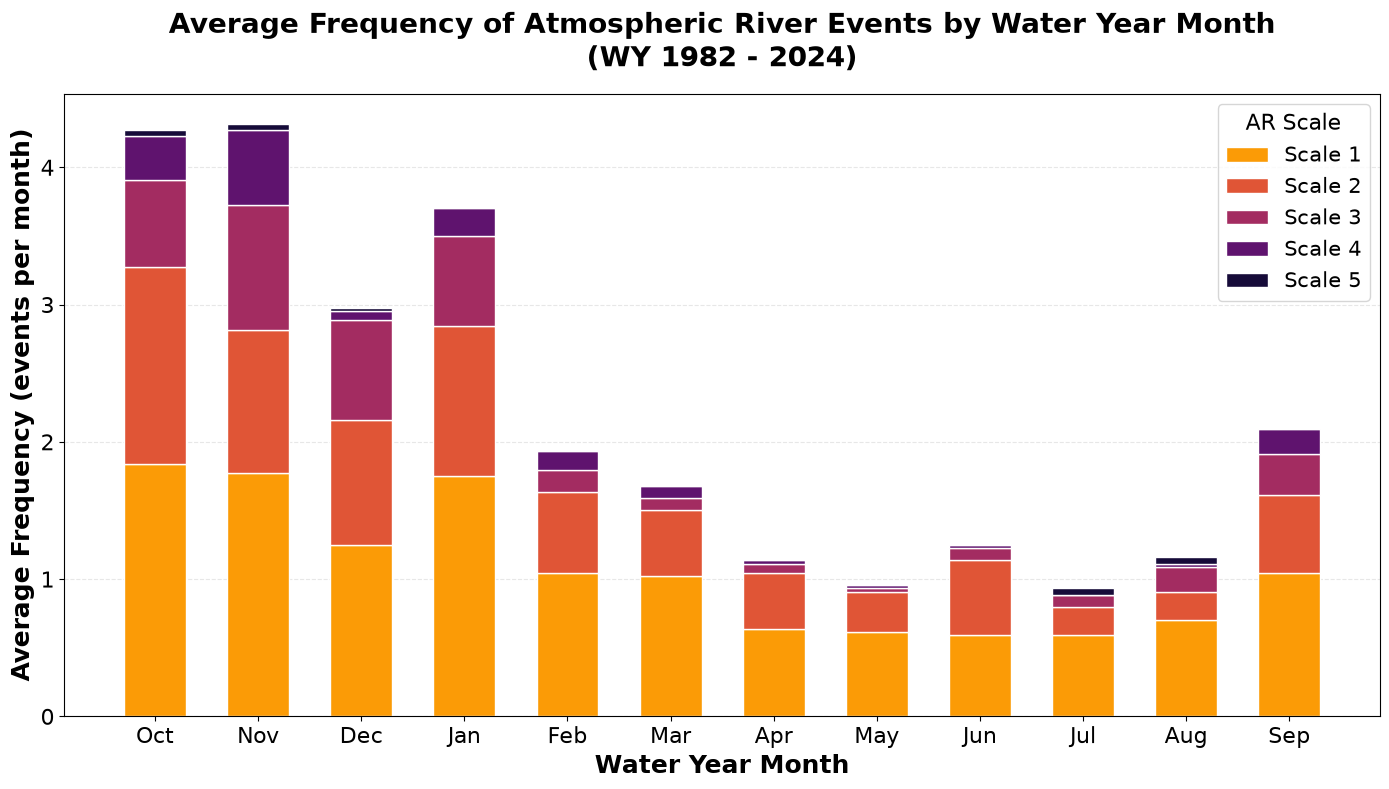


Summary statistics:
Total water years: 44
Total AR events (scale > 0): 1162
Scale 1: 566 total events (avg 12.86 per month)
Scale 2: 341 total events (avg 7.77 per month)
Scale 3: 172 total events (avg 3.93 per month)
Scale 4: 72 total events (avg 1.64 per month)
Scale 5: 9 total events (avg 0.20 per month)


In [81]:
# Month names for water year (Oct-Sept)
water_year_months = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']

# Prepare data
x = np.arange(len(water_year_months))
width = 0.6

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))

# Color palette for scales (excluding 0)
color_map = {1.0: '#fb9b06', 2.0: '#e05536', 3.0: '#a32c61', 4.0: '#5f136e', 5.0: '#160b39'}

# Plot stacked bars for each scale category
bottom = np.zeros(len(water_year_months))
for scale in sorted(pivot_data.columns):
    values = pivot_data[scale].values
    color = color_map.get(scale, '#999999')
    ax.bar(x, values, width, label=f'Scale {int(scale)}', bottom=bottom, color=color, edgecolor='white', linewidth=1)
    bottom += values

ax.set_xlabel('Water Year Month', fontsize=18, fontweight='bold')
ax.set_ylabel('Average Frequency (events per month)', fontsize=18, fontweight='bold')
ax.set_title('Average Frequency of Atmospheric River Events by Water Year Month\n(WY 1982 - 2024)', fontsize=20, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(water_year_months, fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.legend(title='AR Scale', fontsize=15, title_fontsize=16, loc='upper right', ncol=1)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print("\nSummary statistics:")
print(f"Total water years: {num_water_years}")
total_events = pivot_data.sum().sum() * num_water_years
print(f"Total AR events (scale > 0): {int(total_events)}")
for scale in sorted(pivot_data.columns):
    total_for_scale = int(pivot_data[scale].sum() * num_water_years)
    avg_for_scale = pivot_data[scale].sum()
    print(f"Scale {int(scale)}: {total_for_scale} total events (avg {avg_for_scale:.2f} per month)")

## AR Scale Distribution by Streamflow Bucket

In [82]:
# Convert discharge from cfs to cms (1 cms = 35.3147 cfs)
events['discharge_cms'] = events['discharge_cfs'] / 35.3147

# Define streamflow buckets (in cms)
labels_sf = ["< 600", "600 - 1200", "1200 - 1700", "> 1700"]
bins = [0, 600, 1200, 1700, float('inf')]

# Assign each event to a streamflow bucket
events['streamflow_bucket'] = pd.cut(events['discharge_cms'], bins=bins, labels=labels_sf, right=False)

# Group by streamflow bucket and ar_scale, count occurrences
sf_ar_counts = events.groupby(['streamflow_bucket', 'ar_scale']).size().reset_index(name='count')

# Calculate total events per bucket
bucket_totals = events.groupby('streamflow_bucket').size()

# Calculate percentages by dividing count by bucket total
sf_ar_counts['bucket_total'] = sf_ar_counts['streamflow_bucket'].map(bucket_totals).astype(float)
sf_ar_counts['percentage'] = (sf_ar_counts['count'] / sf_ar_counts['bucket_total'] * 100).astype(float)

# Pivot for easier plotting
pivot_percentages = sf_ar_counts.pivot(index='streamflow_bucket', columns='ar_scale', values='percentage').fillna(0)

print("Percentage of AR scales within each streamflow bucket:")
print(pivot_percentages)
print("\nTotal events per streamflow bucket:")
print(bucket_totals)

Percentage of AR scales within each streamflow bucket:
ar_scale                 0.0        1.0        2.0        3.0        4.0  \
streamflow_bucket                                                          
< 600              30.669331  40.159840  20.279720   6.393606   2.197802   
600 - 1200         12.039312  36.363636  28.009828  17.444717   5.896806   
1200 - 1700         0.000000  17.105263  30.263158  36.842105  14.473684   
> 1700              0.000000   8.823529   5.882353  29.411765  44.117647   

ar_scale                 5.0  
streamflow_bucket             
< 600               0.299700  
600 - 1200          0.245700  
1200 - 1700         1.315789  
> 1700             11.764706  

Total events per streamflow bucket:
streamflow_bucket
< 600          1001
600 - 1200      407
1200 - 1700      76
> 1700           34
dtype: int64


/tmp/ipykernel_681927/1730361953.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sf_ar_counts = events.groupby(['streamflow_bucket', 'ar_scale']).size().reset_index(name='count')
/tmp/ipykernel_681927/1730361953.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_totals = events.groupby('streamflow_bucket').size()


Color codes from inferno colormap (reversed):
Scale 0: #f1ef75
Scale 1: #fb9b06
Scale 2: #e05536
Scale 3: #a32c61
Scale 4: #5f136e
Scale 5: #160b39


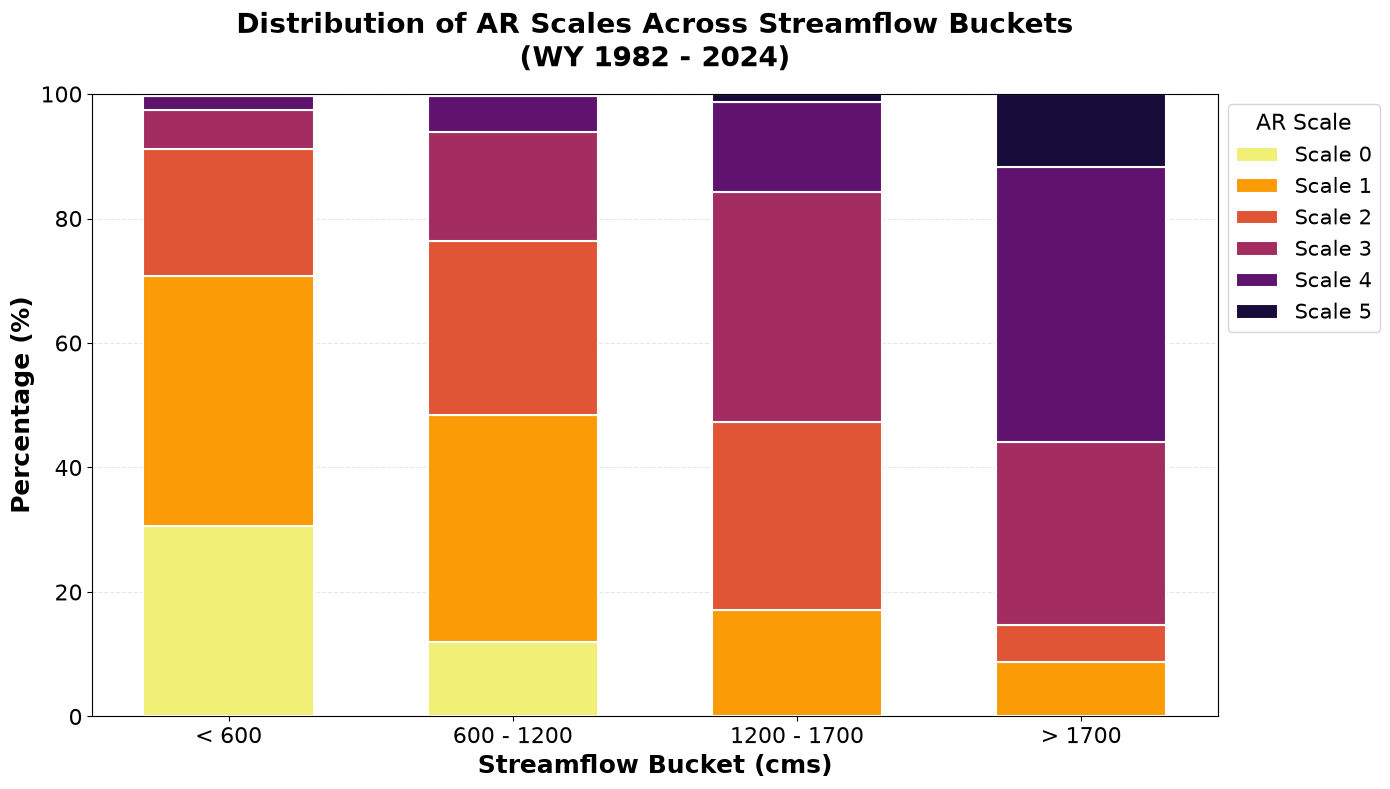


Streamflow bucket statistics:
< 600 cms: 1001 events
600 - 1200 cms: 407 events
1200 - 1700 cms: 76 events
> 1700 cms: 34 events


In [83]:
# Create stacked bar chart for streamflow buckets
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(labels_sf))
width = 0.6

# Color palette from inferno colormap (as hex codes) - reversed
# Scale 0 (lowest) = bright yellow, Scale 5 (highest) = dark violet
cmap = plt.cm.inferno
scales_list = sorted(pivot_percentages.columns)
n_scales = len(scales_list)
color_map = {scale: plt.matplotlib.colors.to_hex(cmap(0.95 - (i / (n_scales - 1)) * 0.85)) for i, scale in enumerate(scales_list)}

print("Color codes from inferno colormap (reversed):")
for scale, color in sorted(color_map.items()):
    print(f"Scale {int(scale)}: {color}")

# Plot stacked bars for each AR scale
bottom = np.zeros(len(labels_sf))
for scale in scales_list:
    values = pivot_percentages[scale].values
    color = color_map[scale]
    ax.bar(x, values, width, label=f'Scale {int(scale)}', bottom=bottom, color=color, edgecolor='white', linewidth=1.5)
    bottom += values

ax.set_xlabel('Streamflow Bucket (cms)', fontsize=18, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=18, fontweight='bold')
ax.set_title('Distribution of AR Scales Across Streamflow Buckets\n(WY 1982 - 2024)', fontsize=20, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels_sf, fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.legend(title='AR Scale', fontsize=15, title_fontsize=16, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\nStreamflow bucket statistics:")
for bucket in labels_sf:
    count = bucket_totals[bucket] if bucket in bucket_totals.index else 0
    print(f"{bucket} cms: {int(count)} events")